In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style
apply_style()

from MixedEffectsModeling.validation import lobo_mmd

LOBO = Path('./LOBO_Results_mixed')
FIG = LOBO / 'Figures'
FIG.mkdir(parents=True, exist_ok=True)

In [5]:
def _p_to_asterisk(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''


def _short_batch_label(batch):
    name, _, num = batch.replace(' et al.', '').partition('_Batch_')
    return f'{name}_{num}' if num else name


def plot_mmd_bar(df, out_path):
    d = df.sort_values('mmd2', ascending=False).reset_index(drop=True)
    labels = [_short_batch_label(b) for b in d['batch']]
    fig, ax = plt.subplots(figsize=(4, 6))
    bars = ax.bar(range(len(d)), d['mmd2'], color='#00C78B')
    y_span = d['mmd2'].max() - d['mmd2'].min()
    for bar, p in zip(bars, d['perm_p']):
        label = _p_to_asterisk(p)
        if not label:
            continue
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01 * y_span, label, ha='center', va='bottom', fontsize=10)
    ax.set_xticks(range(len(d)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('MMD$^2$ (held-out HC vs disease)')
    ax.set_xlabel('LOBO batch')
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches='tight')
    return fig


def plot_mmd_direction(df, out_path):
    d = df.sort_values('mmd2', ascending=False).reset_index(drop=True)
    labels = [_short_batch_label(b) for b in d['batch']]
    y = np.arange(len(d))
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hlines(y, d['hc_ref_dist'], d['dis_ref_dist'],
             color=np.where(d['disease_farther'], '#00C78B', '#999999'), linewidth=3)
    ax.scatter(d['hc_ref_dist'], y, color='#A4AFB8', label='held-out HC', zorder=3, s=90, edgecolors='black', linewidth=0.5)
    ax.scatter(d['dis_ref_dist'], y, color='#00C78B', label='disease', zorder=3, s=90, edgecolors='black', linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel('Distance from HC reference')
    ax.set_ylabel('LOBO batch')
    ax.legend(frameon=False)
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches='tight')
    return fig

In [6]:
# 0. Raw MMD summary (held-out HC vs held-out disease, per Tier-A batch with n_hc >= lobo_mmd.MIN_N_HC)
# no SHASH correction -- Z_test.npy / cv_zscores.pkl are used exactly as scored
df_raw = lobo_mmd.mmd_summary_cached(force=False, shash=False)
print(df_raw.to_string(index=False))

n_sig_raw = int(((df_raw['perm_p'] < 0.05) & df_raw['disease_farther']).sum())
print(f"\n{n_sig_raw}/{len(df_raw)} batches: MMD significant (p<0.05) AND disease farther "
     f"from the in-fold HC reference than the held-out-HC noise floor. (raw, no SHASH)")

                          batch  n_hc  n_dis     mmd2   perm_p  hc_ref_dist  dis_ref_dist  disease_farther
          Ward Z et al._Batch_1   116    224 0.057589 0.000999   136.205461    146.515529             True
           Moore et al._Batch_1    71    173 0.000736 0.224775   138.070108    145.535489             True
Roskams-Hieter B et al._Batch_2    27     58 0.009790 0.036963   141.312959    153.150468             True
       Moufarrej et al._Batch_4    47     39 0.009684 0.058941   127.649357    143.129024             True
            Chen et al._Batch_2    31     32 0.024635 0.011988   136.006374    154.550398             True
       Moufarrej et al._Batch_1    54     23 0.034273 0.002997   127.923300    134.778769             True

4/6 batches: MMD significant (p<0.05) AND disease farther from the in-fold HC reference than the held-out-HC noise floor. (raw, no SHASH)


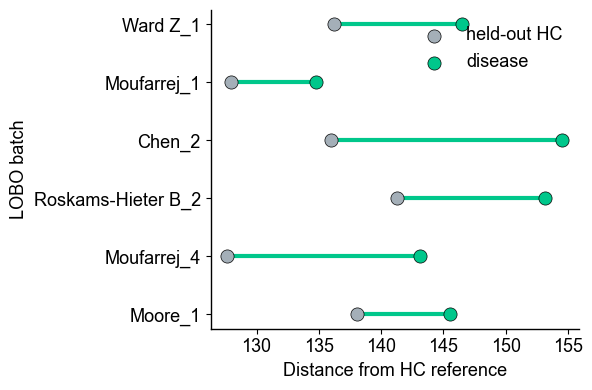

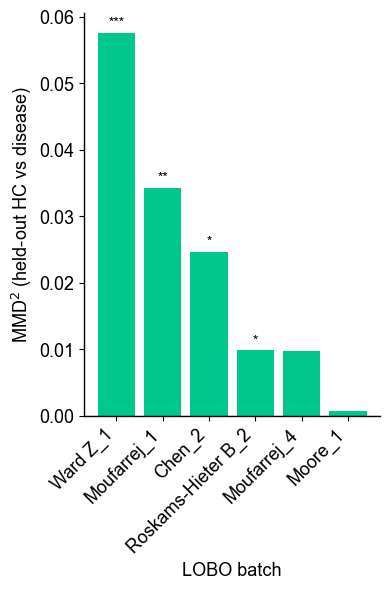

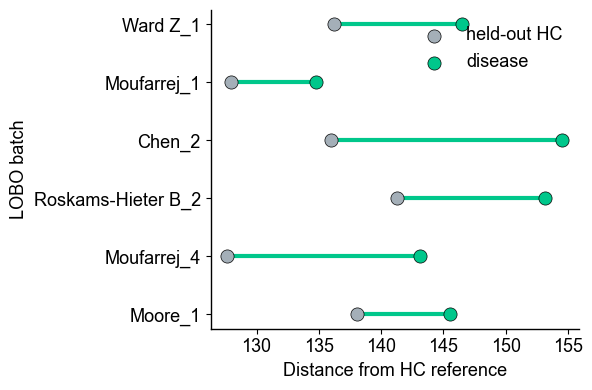

In [7]:
# 1. Raw MMD plots
plot_mmd_bar(df_raw, FIG / 'mmd_bar.png')
plot_mmd_direction(df_raw, FIG / 'mmd_direction.png')

In [8]:
# 2. SHASH-corrected MMD summary -- each gene's already-fit SHASH transform (cv_stats.csv)
# applied to both the LOBO Z and the CV-reference centroid before the comparison
df_shash = lobo_mmd.mmd_summary_cached(force=False, shash=True)
print(df_shash.to_string(index=False))

n_sig_shash = int(((df_shash['perm_p'] < 0.05) & df_shash['disease_farther']).sum())
print(f"\n{n_sig_shash}/{len(df_shash)} batches: MMD significant (p<0.05) AND disease farther "
     f"from the in-fold HC reference than the held-out-HC noise floor. (SHASH-corrected)")

                          batch  n_hc  n_dis     mmd2   perm_p  hc_ref_dist  dis_ref_dist  disease_farther
          Ward Z et al._Batch_1   116    224 0.056021 0.000999   136.506742    144.883128             True
           Moore et al._Batch_1    71    173 0.000610 0.241758   135.430838    141.677410             True
Roskams-Hieter B et al._Batch_2    27     58 0.009409 0.049950   140.171393    151.005762             True
       Moufarrej et al._Batch_4    47     39 0.008227 0.085914   126.817366    140.660972             True
            Chen et al._Batch_2    31     32 0.023517 0.015984   134.142732    149.731821             True
       Moufarrej et al._Batch_1    54     23 0.033363 0.005994   128.126812    133.502790             True

4/6 batches: MMD significant (p<0.05) AND disease farther from the in-fold HC reference than the held-out-HC noise floor. (SHASH-corrected)


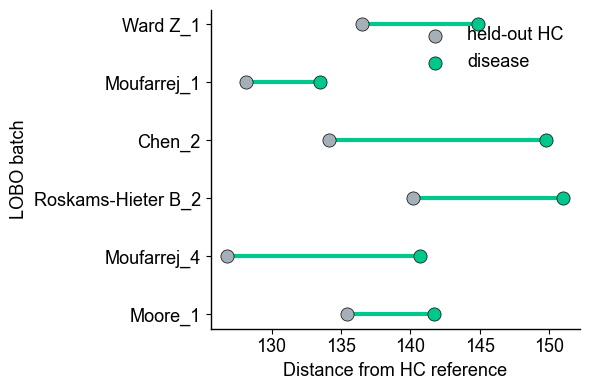

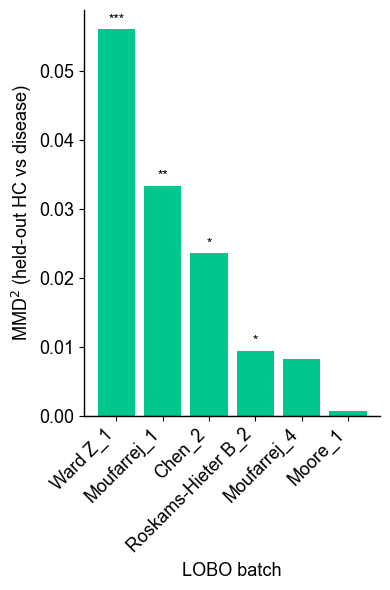

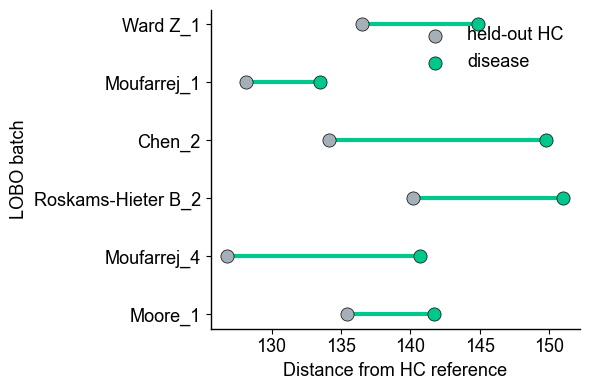

In [9]:
# 3. SHASH-corrected MMD plots
plot_mmd_bar(df_shash, FIG / 'mmd_bar_shash.png')
plot_mmd_direction(df_shash, FIG / 'mmd_direction_shash.png')

In [10]:
# 4. Raw vs SHASH-corrected, side by side -- does the raw-scale call survive de-skewing?
cmp = df_raw.merge(df_shash, on='batch', suffixes=('_raw', '_shash'))
cmp['sig_raw'] = (cmp['perm_p_raw'] < 0.05) & cmp['disease_farther_raw']
cmp['sig_shash'] = (cmp['perm_p_shash'] < 0.05) & cmp['disease_farther_shash']
print(cmp[['batch', 'mmd2_raw', 'perm_p_raw', 'sig_raw', 'mmd2_shash', 'perm_p_shash', 'sig_shash']].to_string(index=False))
print(f"\nagree (both sig or both not): {(cmp['sig_raw'] == cmp['sig_shash']).sum()}/{len(cmp)}")

                          batch  mmd2_raw  perm_p_raw  sig_raw  mmd2_shash  perm_p_shash  sig_shash
          Ward Z et al._Batch_1  0.057589    0.000999     True    0.056021      0.000999       True
           Moore et al._Batch_1  0.000736    0.224775    False    0.000610      0.241758      False
Roskams-Hieter B et al._Batch_2  0.009790    0.036963     True    0.009409      0.049950       True
       Moufarrej et al._Batch_4  0.009684    0.058941    False    0.008227      0.085914      False
            Chen et al._Batch_2  0.024635    0.011988     True    0.023517      0.015984       True
       Moufarrej et al._Batch_1  0.034273    0.002997     True    0.033363      0.005994       True

agree (both sig or both not): 6/6


In [11]:
from MixedEffectsModeling.validation.lobo_engine import compute_ood

compute_ood()

Chang et al._Batch_1                     n_test=  30  removed_OOD=  9 (30.0%)
Chang et al._Batch_11                    n_test=  35  removed_OOD=  0 (0.0%)
Chang et al._Batch_2                     n_test=  37  removed_OOD=  0 (0.0%)
Chang et al._Batch_3                     n_test=  30  removed_OOD=  1 (3.3%)
Chang et al._Batch_4                     n_test=  33  removed_OOD=  0 (0.0%)
Chang et al._Batch_5                     n_test=  25  removed_OOD=  0 (0.0%)
Chen et al._Batch_2                      n_test=  63  removed_OOD=  5 (7.9%)
Gardella et al._Batch_1                  n_test=  30  removed_OOD=  0 (0.0%)
Gardella et al._Batch_3                  n_test=  14  removed_OOD=  1 (7.1%)
Gardella et al._Batch_4                  n_test=  46  removed_OOD=  0 (0.0%)
Gardella et al._Batch_5                  n_test=  32  removed_OOD=  0 (0.0%)
Gardella et al._Batch_7                  n_test=  17  removed_OOD=  0 (0.0%)
Moore et al._Batch_1                     n_test= 244  removed_OOD= 16 (6.6%

In [12]:
# OOD-filtered MMD, raw and SHASH-corrected
df_ood = lobo_mmd.mmd_summary_cached(force=False, shash=False, ood_filter=True)
df_shash_ood = lobo_mmd.mmd_summary_cached(force=False, shash=True, ood_filter=True)

for label, d in [('ood', df_ood), ('shash+ood', df_shash_ood)]:
    n_sig = int(((d['perm_p'] < 0.05) & d['disease_farther']).sum())
    print(f"[{label}] {n_sig}/{len(d)} batches significant (p<0.05) AND disease farther")
print()
print(df_shash_ood.to_string(index=False))

[ood] 4/6 batches significant (p<0.05) AND disease farther
[shash+ood] 4/6 batches significant (p<0.05) AND disease farther

                          batch  n_hc  n_dis      mmd2   perm_p  hc_ref_dist  dis_ref_dist  disease_farther
          Ward Z et al._Batch_1   105    194  0.051337 0.000999   137.748850    143.059284             True
           Moore et al._Batch_1    67    161 -0.000164 0.370629   135.031549    140.778781             True
Roskams-Hieter B et al._Batch_2    26     57  0.010340 0.042957   140.379433    150.018712             True
            Chen et al._Batch_2    28     30  0.028544 0.014985   130.698211    146.343899             True
       Moufarrej et al._Batch_4    42     30  0.006066 0.152847   126.315922    138.103543             True
       Moufarrej et al._Batch_1    48     19  0.037694 0.002997   127.040137    136.378123             True


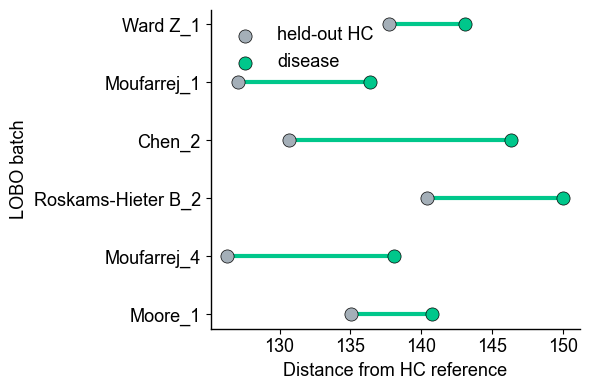

In [13]:
# shash+ood plots (the most rigorous variant: batch-refit + SHASH-decorrelated + extrapolation-flagged)
plot_mmd_bar(df_shash_ood, FIG / 'mmd_bar_shash_ood.png')
plot_mmd_direction(df_shash_ood, FIG / 'mmd_direction_shash_ood.png')

In [14]:
# All 4 variants side by side -- does the raw-scale call survive de-skewing AND extrapolation-flagging?
variants = {'raw': df_raw, 'shash': df_shash, 'ood': df_ood, 'shash_ood': df_shash_ood}
sig = pd.DataFrame({name: (d.set_index('batch')['perm_p'] < 0.05) & d.set_index('batch')['disease_farther']
                    for name, d in variants.items()})
mmd2 = pd.DataFrame({name: d.set_index('batch')['mmd2'] for name, d in variants.items()})

print('significant (p<0.05) AND disease farther, per variant:')
print(sig.to_string())
print(f"\nagree across all 4 variants: {(sig.nunique(axis=1) == 1).sum()}/{len(sig)} batches")
print('\nmmd2 by variant:')
print(mmd2.round(4).to_string())

significant (p<0.05) AND disease farther, per variant:
                                   raw  shash    ood  shash_ood
batch                                                          
Chen et al._Batch_2               True   True   True       True
Moore et al._Batch_1             False  False  False      False
Moufarrej et al._Batch_1          True   True   True       True
Moufarrej et al._Batch_4         False  False  False      False
Roskams-Hieter B et al._Batch_2   True   True   True       True
Ward Z et al._Batch_1             True   True   True       True

agree across all 4 variants: 6/6 batches

mmd2 by variant:
                                    raw   shash     ood  shash_ood
batch                                                             
Chen et al._Batch_2              0.0246  0.0235  0.0304     0.0285
Moore et al._Batch_1             0.0007  0.0006  0.0001    -0.0002
Moufarrej et al._Batch_1         0.0343  0.0334  0.0389     0.0377
Moufarrej et al._Batch_4         0.009